In [21]:
# Bibliotecas #
from Filtro_LS import filtro_LS0
from Filtro_LS import filtro_LS1
from Filtro_LS import filtro_LS_2
from Funcoes_auxiliares import *
from Gerador_de_Sinais import main as leitura_shaper
from Gerador_de_Sinais import original_signal_generator
from numpy.linalg import pinv as inversa

In [22]:
# Consantes & Variáveis #
quantidade_de_amostras = 10000
# dt = 25 * 10**-9  # tempo entre amostras. Dados proveniente do Shaper
# fs = 1 / dt  # frequência de amostragem. 40 MHz
# resoluçao = fs / quantidade_de_amostras
seed = None

In [23]:
# Gerador de sinais #
sinal_original = original_signal_generator(quantidade_de_amostras, seed=seed)
Readout_Shaper = leitura_shaper(sinal_original, seed=seed)

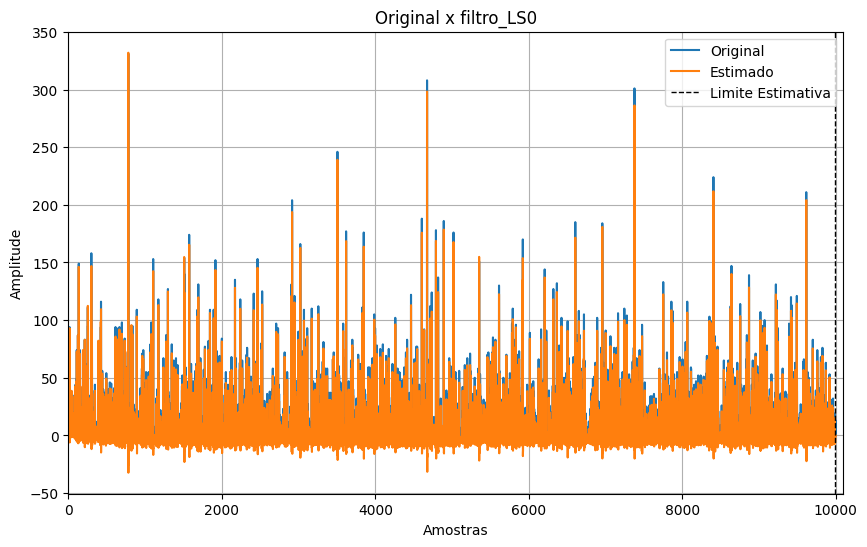

In [24]:
# Filtro 0 #
ordem_filtro0 = 7

sinal_estimado0 = filtro_LS0(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_filtro0,
    # delay=2,
)
# sinal_estimado0 = np.clip(sinal_estimado0, 0, None)

plot_estimado_x_original(
    sinal_original,
    estimado=sinal_estimado0,
    ordem=ordem_filtro0,
    title="Original x filtro_LS0",
)

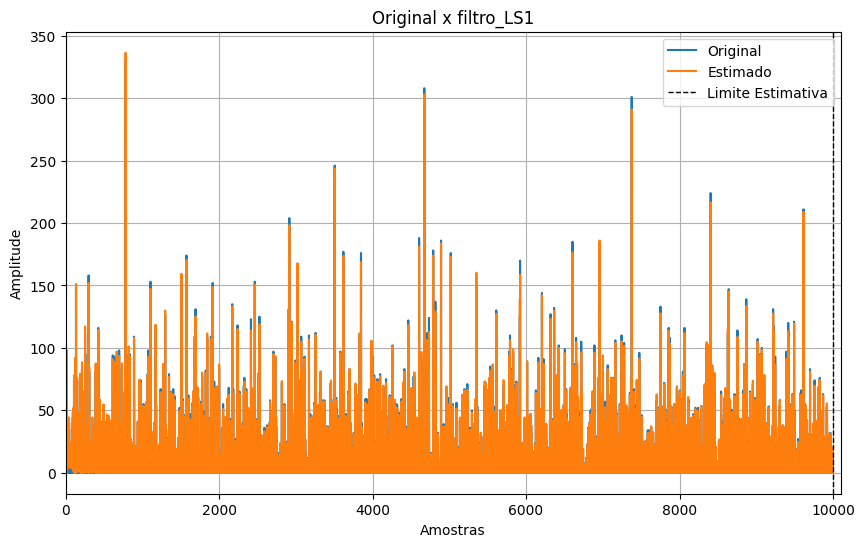

In [25]:
# Filtro 1 #

ordem_filtro1 = 7
delay1 = 2

sinal_estimado1, pesos1, bias1 = filtro_LS1(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_filtro1,
    delay=delay1,
)

plot_estimado_x_original(
    sinal_original,
    estimado=sinal_estimado1,
    ordem=ordem_filtro1,
    title="Original x filtro_LS1",
)

In [26]:
pesos1, bias1

(array([ 0.0520383 , -0.26228569,  1.09748327, -0.2281994 ,  0.07050595,
         0.06728105, -0.04353701]),
 np.float64(5.724430934034153))

In [27]:
# Aplicando pesos calculados em um sinal nao visto antes #

# sinal novo
sinal_original_2 = original_signal_generator(
    quantidade_de_amostras, seed=seed + 9 if seed is not None else None
)

Readout_Shaper_2 = leitura_shaper(
    sinal_original_2, seed=seed + 9 if seed is not None else None
)

# aplicando filtro #
qntd_leitura = len(Readout_Shaper_2)

# Sinal Estimado/Recuperado
sinal_estimado_2 = np.zeros(qntd_leitura, dtype=float)

# Tamanho do sinal estimado
len_sinal_estimado = qntd_leitura - ordem_filtro1 + 1

# Parte adaptativa do filtro
for i in range(len_sinal_estimado):
    sinal_estimado_2[i] = (
        np.dot(Readout_Shaper_2[i : i + ordem_filtro1], pesos1) + bias1
    )

sinal_estimado_2 = np.clip(sinal_estimado_2, 0, None)

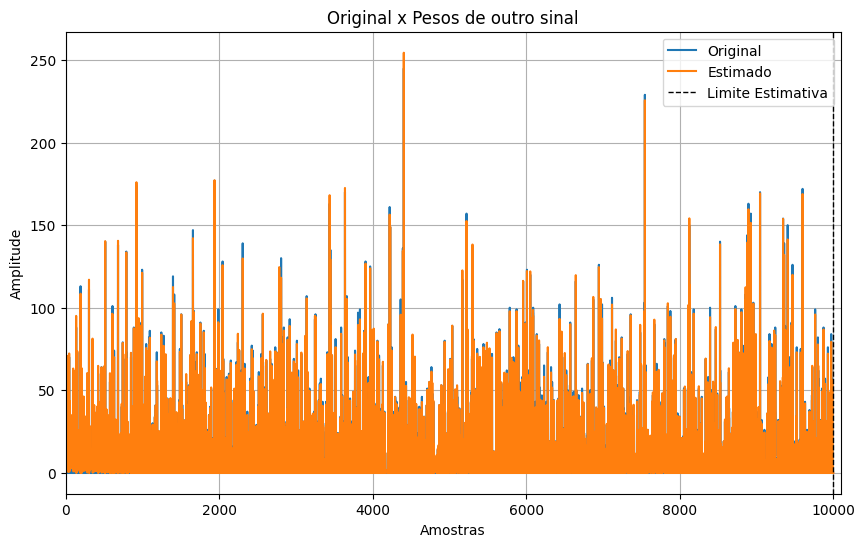

In [28]:
lelen = qntd_leitura - ordem_filtro1 + 1
plot_estimado_x_original(
    sinal_original_2[:lelen],
    estimado=sinal_estimado_2,
    title="Original x Pesos de outro sinal",
)

In [29]:
rmse, erro_abs_medio = RMSE_e_MAE_por_ordem(
    sinal_original_2[:lelen],
    sinal_estimado_2[:lelen],
    printar=True,
)

erro_abs_medio = 1.2247
rmse = 2.2546


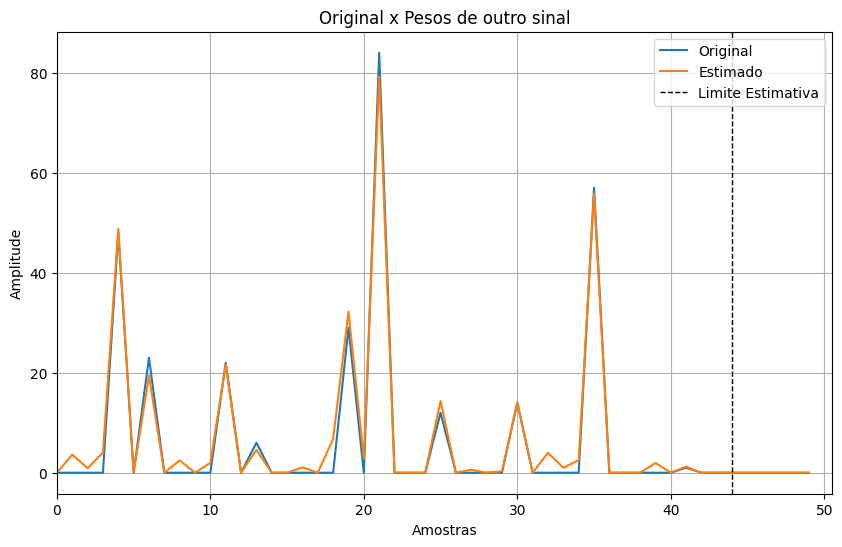

In [31]:
plot_estimado_x_original(
    sinal_original_2[-50:],
    estimado=sinal_estimado_2[-50:],
    title="Original x Pesos de outro sinal",
)